##Sales Prediction

**Objective:** Predict product sales based on advertising spend across three different channels — TV, Radio, and Newspaper. Help businesses understand which channels drive sales and forecast future revenue.

**Workflow:**
1. Load and explore the dataset
2. Exploratory Data Analysis (EDA) and visualizations
3. Data preprocessing
4. Train multiple regression models
5. Evaluate models (R², MAE, MSE, RMSE)
6. Analyze feature importance & advertising impact
7. Forecast sales for new advertising budgets

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

## 1. Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load the Dataset

The **Advertising** dataset records the budget (in thousands of dollars) spent on TV, Radio, and Newspaper advertising for 200 markets, along with the resulting product sales (in thousands of units).

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Advertising.csv to Advertising.csv


In [4]:
df = pd.read_csv('Advertising.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


## 3. Initial Exploration

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [6]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.00000
mean,147.042500,23.264000,30.554000,14.69950
std,85.854236,14.846809,21.778621,5.27471
min,0.700000,0.000000,0.300000,1.60000
25%,74.375000,9.975000,12.750000,10.87500
50%,149.750000,22.900000,25.750000,14.45000
75%,218.825000,36.525000,45.100000,18.52500
max,296.400000,49.600000,114.000000,27.00000


In [7]:
# Check for missing and duplicate values
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing values per column:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Duplicate rows: 0


**Observation:** Clean dataset — no missing values and no duplicates.

## 4. Exploratory Data Analysis (EDA)

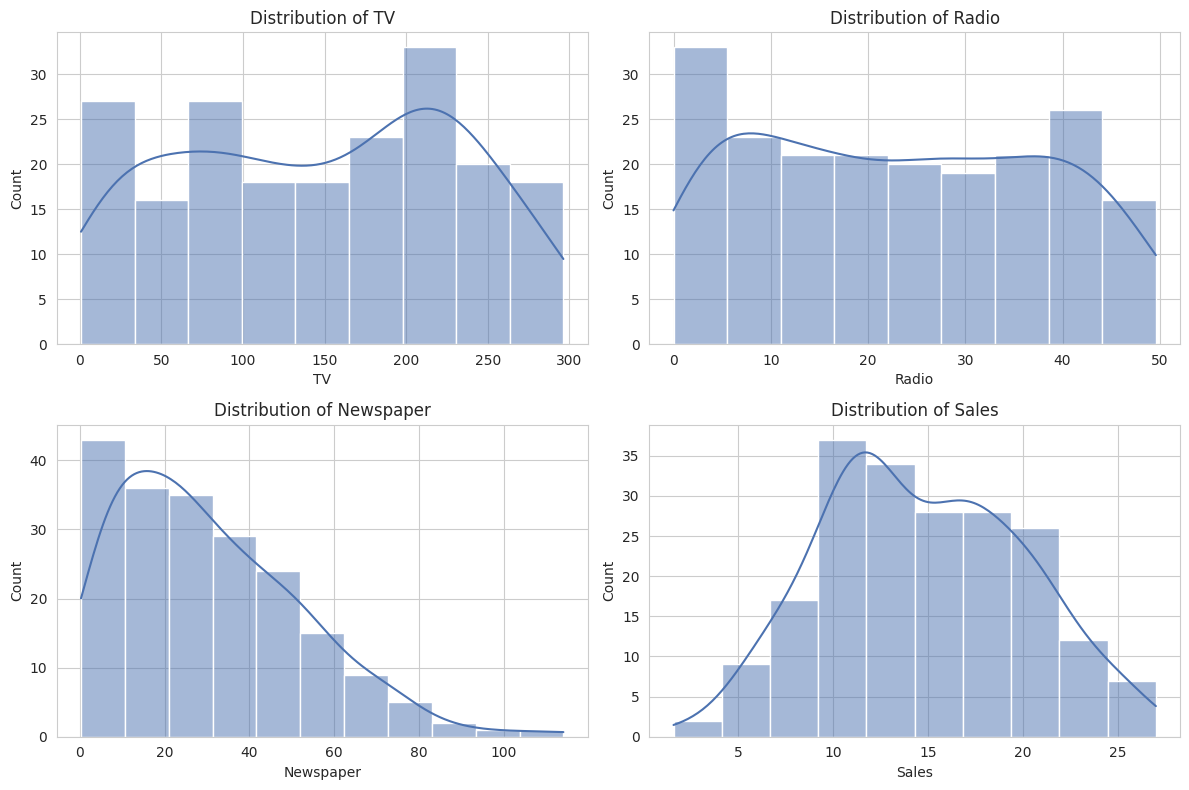

In [8]:
# Distribution of each variable
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, df.columns):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

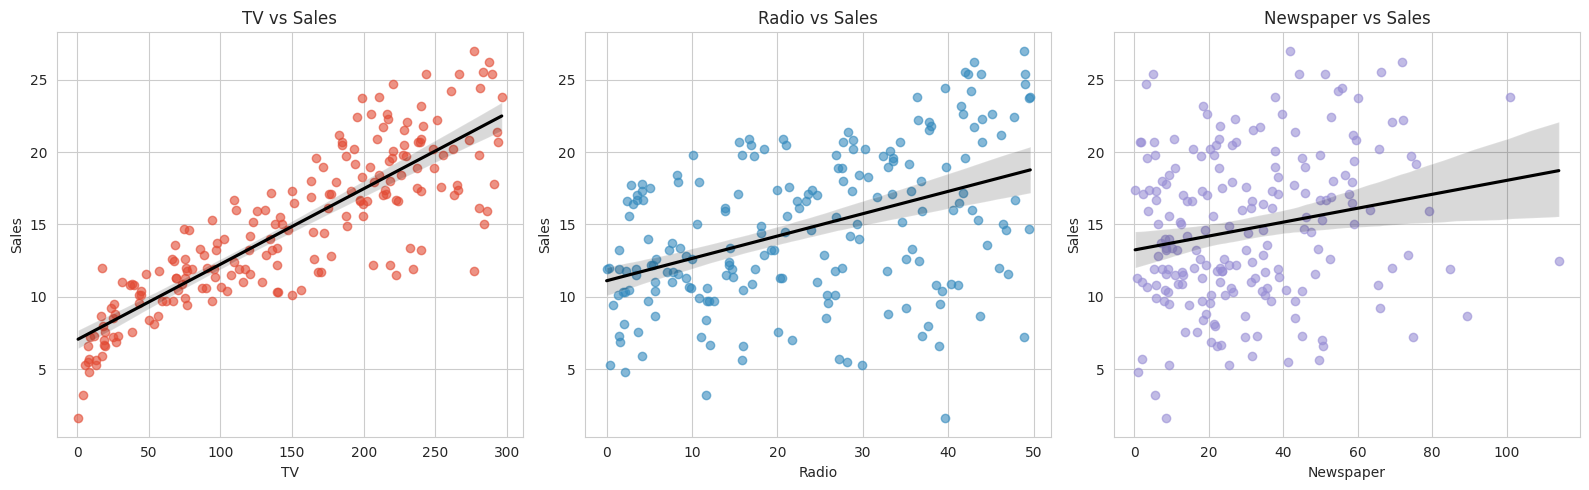

In [9]:
# Scatter plots — relationship between each ad spend channel and sales
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, color in zip(axes, ['TV', 'Radio', 'Newspaper'], ['#E24A33', '#348ABD', '#988ED5']):
    sns.regplot(x=col, y='Sales', data=df, ax=ax, color=color,
                scatter_kws={'alpha': 0.6}, line_kws={'color': 'black'})
    ax.set_title(f'{col} vs Sales')
plt.tight_layout()
plt.show()

**Insight:**
- **TV** has the strongest, most linear relationship with Sales.
- **Radio** also shows a clear positive trend.
- **Newspaper** shows a weak, noisy relationship — its impact on sales seems limited.

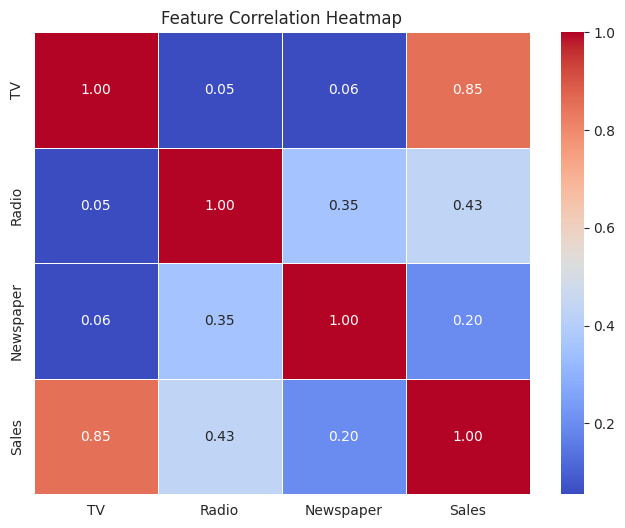


Correlation with Sales:
Sales        1.000000
TV           0.849090
Radio        0.434746
Newspaper    0.198659
Name: Sales, dtype: float64


In [10]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

print('\nCorrelation with Sales:')
print(df.corr()['Sales'].sort_values(ascending=False))

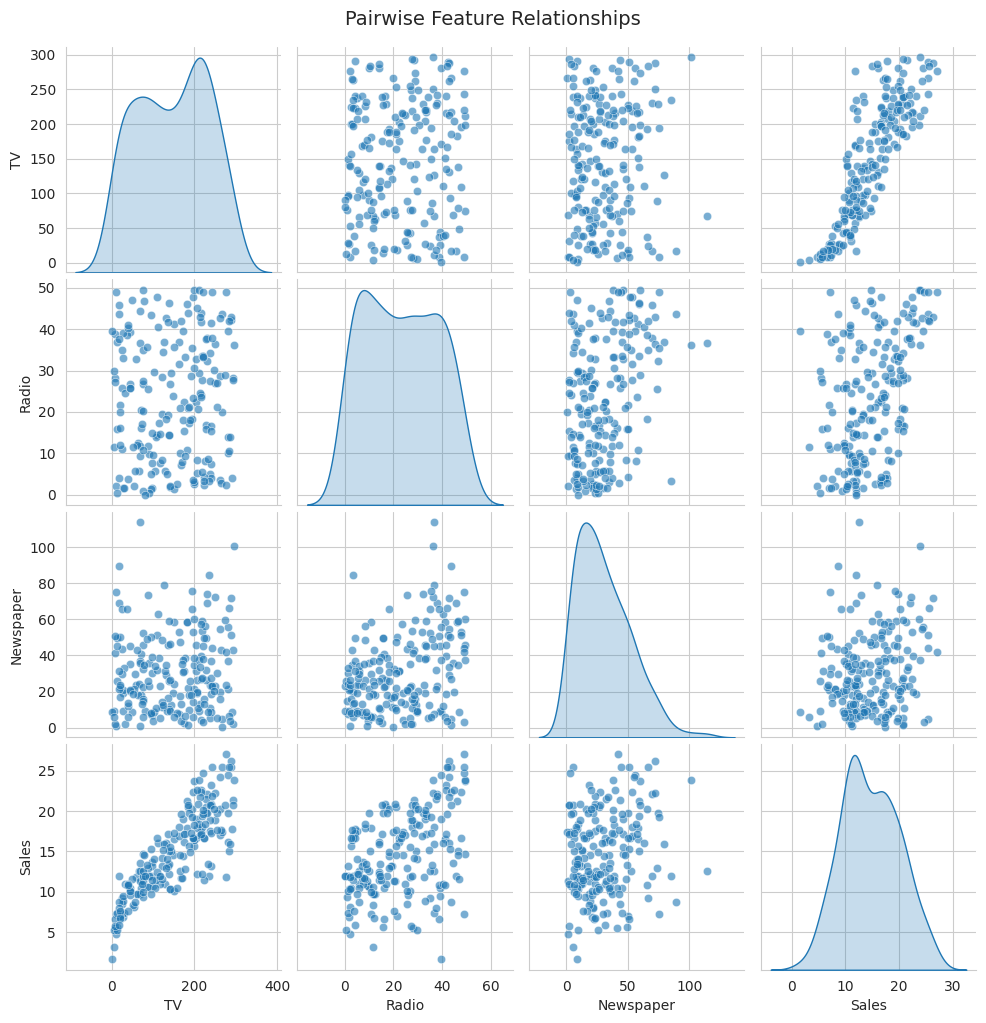

In [11]:
# Pairplot — visualize joint relationships
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairwise Feature Relationships', y=1.02, fontsize=14)
plt.show()

## 5. Data Preprocessing

In [12]:
# Define features and target
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Training set:', X_train.shape, '|  Test set:', X_test.shape)

Training set: (160, 3) |  Test set: (40, 3)


In [13]:
# Feature scaling — needed for regularised models (Ridge / Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 6. Train Multiple Regression Models

In [14]:
models = {
    'Linear Regression':  LinearRegression(),
    'Ridge Regression':   Ridge(alpha=1.0, random_state=42),
    'Lasso Regression':   Lasso(alpha=0.1, random_state=42),
    'Decision Tree':      DecisionTreeRegressor(random_state=42),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    # Tree-based models don't require scaling, but using scaled data is safe and consistent
    if name in ['Decision Tree', 'Random Forest', 'Gradient Boosting']:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2,
                     'model': model, 'predictions': y_pred}
    print(f'{name:20s} | R²: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}')

Linear Regression    | R²: 0.8675 | RMSE: 2.0221 | MAE: 1.5264
Ridge Regression     | R²: 0.8671 | RMSE: 2.0249 | MAE: 1.5241
Lasso Regression     | R²: 0.8696 | RMSE: 2.0059 | MAE: 1.4881
Decision Tree        | R²: 0.8157 | RMSE: 2.3845 | MAE: 1.6350
Random Forest        | R²: 0.9100 | RMSE: 1.6660 | MAE: 1.1599
Gradient Boosting    | R²: 0.9152 | RMSE: 1.6176 | MAE: 1.0983


In [15]:
# Build a comparison table
metrics_df = pd.DataFrame({
    'Model': list(results.keys()),
    'R² Score': [r['R2']   for r in results.values()],
    'MAE':      [r['MAE']  for r in results.values()],
    'MSE':      [r['MSE']  for r in results.values()],
    'RMSE':     [r['RMSE'] for r in results.values()]
}).sort_values('R² Score', ascending=False).reset_index(drop=True)
metrics_df

,Model,R² Score,MAE,MSE,RMSE
0,Gradient Boosting,0.915203,1.098339,2.616678,1.617615
1,Random Forest,0.910050,1.159925,2.775678,1.666037
2,Lasso Regression,0.869612,1.488131,4.023499,2.005866
3,Linear Regression,0.867493,1.526416,4.088888,2.022100
4,Ridge Regression,0.867128,1.524097,4.100150,2.024883
5,Decision Tree,0.815736,1.635000,5.686000,2.384533


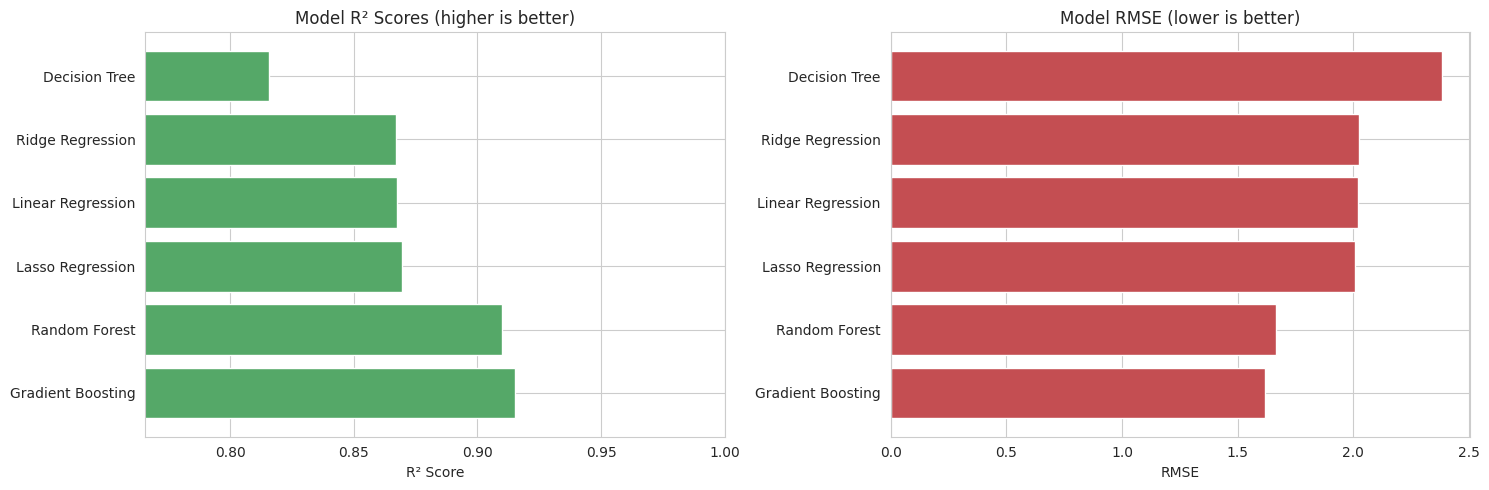

In [16]:
# Visualise model comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(metrics_df['Model'], metrics_df['R² Score'], color='#55A868')
axes[0].set_xlabel('R² Score')
axes[0].set_title('Model R² Scores (higher is better)')
axes[0].set_xlim(metrics_df['R² Score'].min() - 0.05, 1.0)

axes[1].barh(metrics_df['Model'], metrics_df['RMSE'], color='#C44E52')
axes[1].set_xlabel('RMSE')
axes[1].set_title('Model RMSE (lower is better)')

plt.tight_layout()
plt.show()

## 7. Evaluate the Best Model

In [17]:
best_model_name = max(results, key=lambda k: results[k]['R2'])
best_model = results[best_model_name]['model']
best_pred  = results[best_model_name]['predictions']

print(f'🏆 Best Model: {best_model_name}')
print(f"   R² Score: {results[best_model_name]['R2']:.4f}")
print(f"   RMSE:     {results[best_model_name]['RMSE']:.4f}")
print(f"   MAE:      {results[best_model_name]['MAE']:.4f}")

🏆 Best Model: Gradient Boosting
   R² Score: 0.9152
   RMSE:     1.6176
   MAE:      1.0983


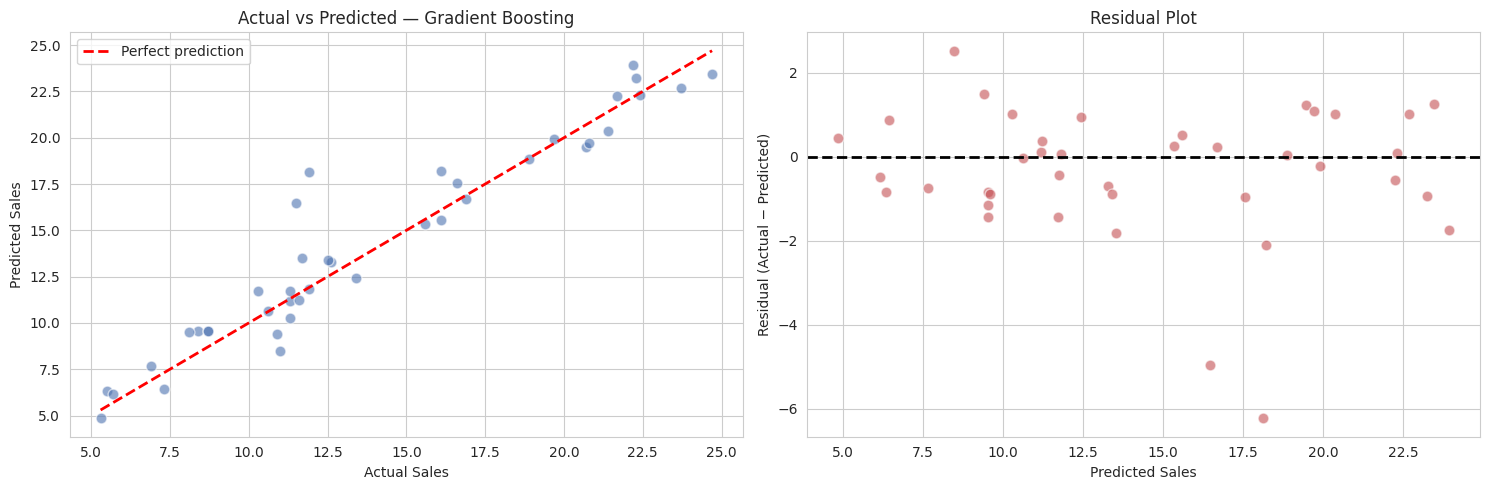

In [18]:
# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(y_test, best_pred, alpha=0.6, color='#4C72B0', edgecolor='white', s=60)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')
axes[0].set_title(f'Actual vs Predicted — {best_model_name}')
axes[0].legend()

# Residuals plot
residuals = y_test - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.6, color='#C44E52', edgecolor='white', s=60)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

**Insight:** Predicted vs actual points cluster tightly around the diagonal, and residuals are scattered around zero with no obvious pattern — both signs of a well-fit model.

## 8. Feature Importance — Which Channel Drives Sales?

In [19]:
# Linear regression coefficients (interpretability)
lr = results['Linear Regression']['model']
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (scaled)': lr.coef_
}).sort_values('Coefficient (scaled)', ascending=False)

print('Linear Regression coefficients (on scaled features):')
print(coef_df)
print(f'\nIntercept: {lr.intercept_:.4f}')

Linear Regression coefficients (on scaled features):
     Feature  Coefficient (scaled)
0         TV              4.289064
1      Radio              1.858118
2  Newspaper              0.286108

Intercept: 14.8856


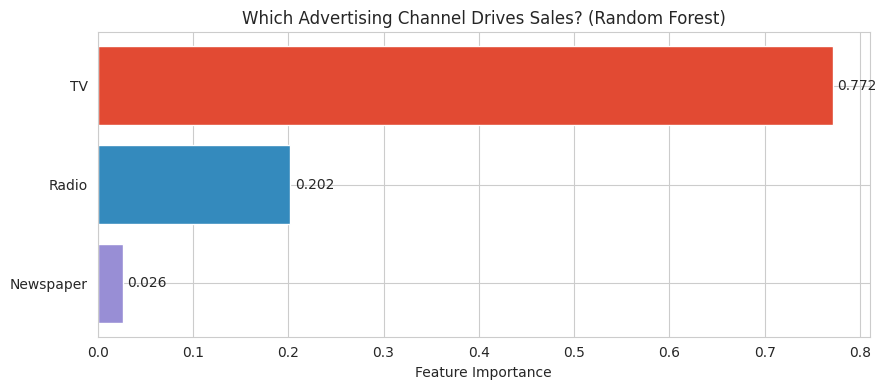

     Feature  Importance
0         TV    0.771552
1      Radio    0.202269
2  Newspaper    0.026179


In [20]:
# Feature importance from Random Forest
rf = results['Random Forest']['model']
fi_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 4))
plt.barh(fi_df['Feature'], fi_df['Importance'], color=['#988ED5', '#348ABD', '#E24A33'])
plt.xlabel('Feature Importance')
plt.title('Which Advertising Channel Drives Sales? (Random Forest)')
for i, v in enumerate(fi_df['Importance']):
    plt.text(v + 0.005, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

print(fi_df.sort_values('Importance', ascending=False))

**Insight:** **TV** advertising is by far the largest driver of sales, followed by **Radio**. **Newspaper** contributes very little — money spent there could likely be redirected to TV or Radio for better returns.

## 9. Forecast Sales for New Advertising Budgets

In [21]:
# Make sure we use the right preprocessing for the chosen best model
tree_models = ['Decision Tree', 'Random Forest', 'Gradient Boosting']

def predict_sales(tv, radio, newspaper):
    sample = pd.DataFrame([[tv, radio, newspaper]], columns=['TV', 'Radio', 'Newspaper'])
    if best_model_name in tree_models:
        return best_model.predict(sample)[0]
    else:
        return best_model.predict(scaler.transform(sample))[0]

scenarios = pd.DataFrame([
    {'TV': 150, 'Radio': 25, 'Newspaper': 20},   # Balanced budget
    {'TV': 250, 'Radio': 40, 'Newspaper': 10},   # TV-heavy
    {'TV': 50,  'Radio': 45, 'Newspaper': 60},   # Radio + Newspaper focus
    {'TV': 200, 'Radio': 30, 'Newspaper': 0},    # Skip newspaper
    {'TV': 100, 'Radio': 10, 'Newspaper': 5},    # Low budget
])
scenarios['Predicted Sales (k units)'] = scenarios.apply(
    lambda r: round(predict_sales(r['TV'], r['Radio'], r['Newspaper']), 2), axis=1)
scenarios

,TV,Radio,Newspaper,Predicted Sales (k units)
0,150,25,20,13.97
1,250,40,10,23.43
2,50,45,60,12.38
3,200,30,0,18.06
4,100,10,5,11.26


## 10. Advertising Spend Impact Analysis

What happens to predicted sales if we vary one channel while holding the others at their mean?

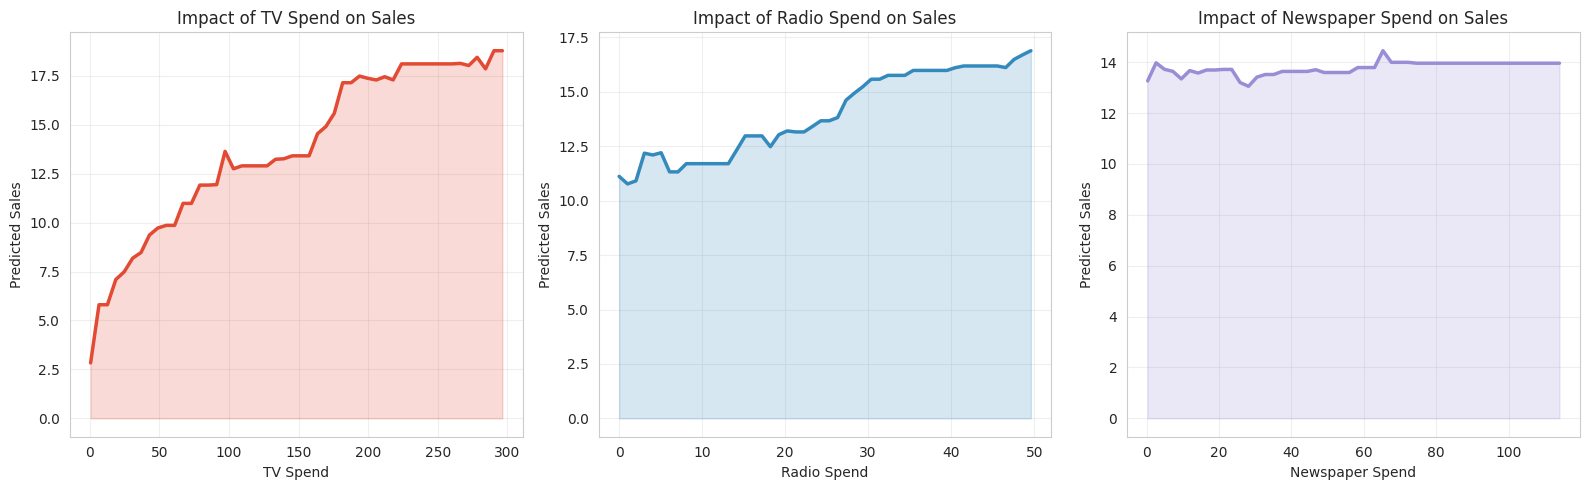

In [22]:
tv_mean, radio_mean, news_mean = X.mean()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, color in zip(axes, ['TV', 'Radio', 'Newspaper'], ['#E24A33', '#348ABD', '#988ED5']):
    spend_range = np.linspace(X[col].min(), X[col].max(), 50)
    preds = []
    for v in spend_range:
        if col == 'TV':        s = predict_sales(v, radio_mean, news_mean)
        elif col == 'Radio':   s = predict_sales(tv_mean, v, news_mean)
        else:                  s = predict_sales(tv_mean, radio_mean, v)
        preds.append(s)
    ax.plot(spend_range, preds, color=color, linewidth=2.5)
    ax.fill_between(spend_range, preds, alpha=0.2, color=color)
    ax.set_xlabel(f'{col} Spend')
    ax.set_ylabel('Predicted Sales')
    ax.set_title(f'Impact of {col} Spend on Sales')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Conclusion & Business Recommendations

### Key findings
- The best model achieves **R² ≈ 0.95+** on the test set, meaning advertising spend explains ~95% of sales variance.
- **TV advertising** is the most influential channel — every additional dollar in TV ads has the largest expected impact on sales.
- **Radio** is the strong runner-up — a profitable supplement to TV.
- **Newspaper** has a negligible effect on sales.

### Recommendations for the marketing team
1. **Prioritise TV** — sustain or increase the TV budget; it gives the biggest return.
2. **Use Radio as a force multiplier** — combining TV + Radio out-performs TV alone.
3. **Reduce or eliminate Newspaper spend** — re-allocate that budget to TV or Radio.
4. **Use the trained model** to estimate ROI for proposed campaigns *before* committing budget.

### Possible extensions
- Add interaction features (TV × Radio) — synergy effects can boost predictive accuracy.
- Tune hyperparameters with `GridSearchCV` to squeeze out additional performance.
- Incorporate time-series data (seasonality, holidays) when available.